In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["MedHouseValue"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64


In [4]:
X = df.drop("MedHouseValue", axis=1)

y = df["MedHouseValue"]

print("Input Features:")
print(X.columns)

print("\nTarget Variable:")
print(y.name)

Input Features:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Target Variable:
MedHouseValue


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed Successfully!")
print("Intercept:", model.intercept_)

Model Training Completed Successfully!
Intercept: -37.023277706064064


In [7]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nRegression Coefficients:")
print(coefficients)

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": y_pred
})

results.head(10)


Regression Coefficients:
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


,Actual Value,Predicted Value
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [8]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("------------------------")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared Score (R²):", r2)

Model Evaluation Metrics
------------------------
Mean Squared Error (MSE): 0.555891598695244
Root Mean Squared Error (RMSE): 0.7455813830127761
R-squared Score (R²): 0.5757877060324511


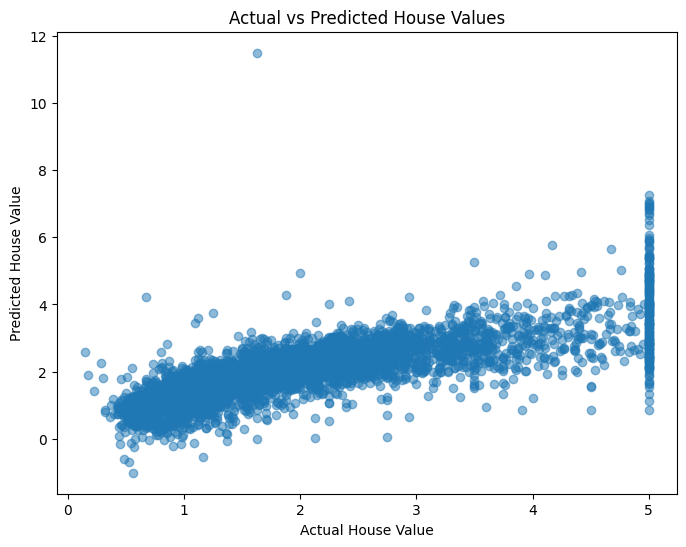

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.show()

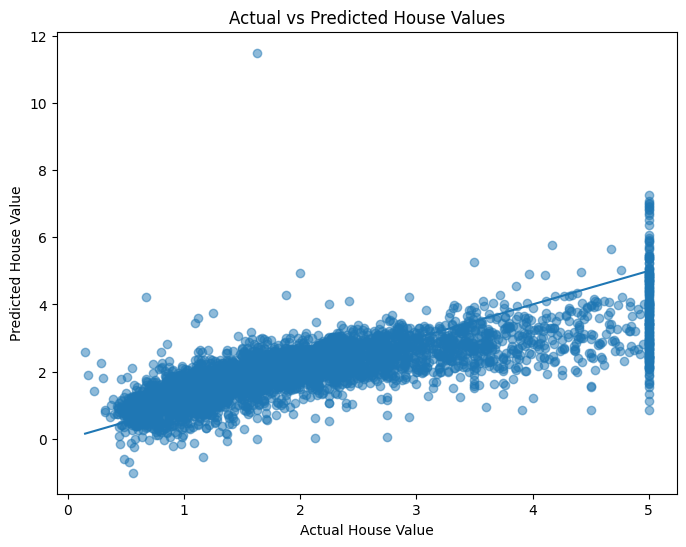

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.show()

20046   -0.242123
3024    -1.306017
15663    2.290351
20484   -0.652926
9814     0.175343
13311   -0.424754
7113    -0.663500
7668    -0.593755
18246    0.659254
5723     0.550385
Name: MedHouseValue, dtype: float64


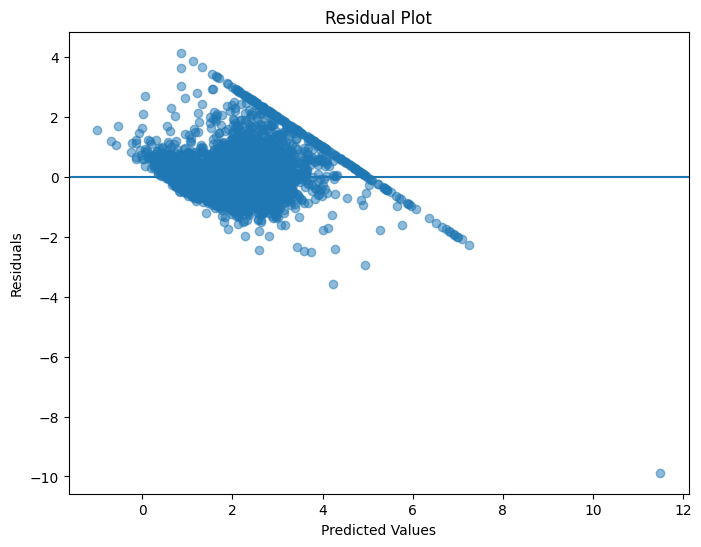

In [11]:
residuals = y_test - y_pred

print(residuals[:10])

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [12]:
print("MULTIPLE LINEAR REGRESSION MODEL SUMMARY")
print("-----------------------------------------")
print("Dataset: California Housing Dataset")
print("Total Features:", X.shape[1])
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

print("\nEvaluation Metrics:")
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

if r2 >= 0.7:
    print("\nConclusion: The model has good predictive capability.")
elif r2 >= 0.5:
    print("\nConclusion: The model has moderate predictive capability.")
else:
    print("\nConclusion: The model has limited predictive capability.")

MULTIPLE LINEAR REGRESSION MODEL SUMMARY
-----------------------------------------
Dataset: California Housing Dataset
Total Features: 8
Training Samples: 16512
Testing Samples: 4128

Evaluation Metrics:
MSE: 0.5559
RMSE: 0.7456
R² Score: 0.5758

Conclusion: The model has moderate predictive capability.
